In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
pAB=[[[0.1,0.6] , [0.2,0.2]],
     [[0.7,0.2] , [0.3,0.3]]]

### node switching probability matrix
    # top row applies to a node if it is OFF
    # bottom applies if it is ON

    # left column applies if the nodes are connected
        # within it the left-left column applies when the nodes are like
        # and the right-left column when they are unlike (A xor B = True)
    # right applies if they are not 
        # the two subcolumns are identical: other node doesn't matter when the connection is gone

In [25]:
pE=[[[0.5,0.5] , [0.6,0.6]],
    [[0.3,0.3] , [0.4,0.4]]]

### connectedness switching probability matrix
    # top row applies if connection is not there
    # bottom applies if it already is.

    # left column applies if the nodes are like
        # within it the left-left column applies when the nodes are both ON
        # and the right-left column when they are OFF
    # right column applies if they are unlike (A xor B = True)
        # the two subcolumns are identical: only one possible way for them to be unlike, as they are equivalent nodes

In [26]:
# starting state (one out of the 2^3 = 8 possible states)
A = True # state of one node
B = True # state of the other node
E = False # nodes connected?

In [66]:
n_updates = 200

Events = np.empty((n_updates+1, 3), dtype=np.bool)
Events[0,:] = [A, B, E]

for t in range(n_updates):
    At, Bt, Et = Events[t].astype(np.uint8)
    ABlike = int(At!=Bt)
    Events[t+1] = np.random.uniform(size=3) < [ pAB[At][Et][ABlike] , pAB[Bt][Et][ABlike] , pE[Et][ABlike][At*Bt] ]

In [ ]:
saveto = ''
np.savez(saveto, pAB=np.asarray(pAB, dtype=np.float16), pE=np.asarray(pE, dtype=np.float16), Events=Events)

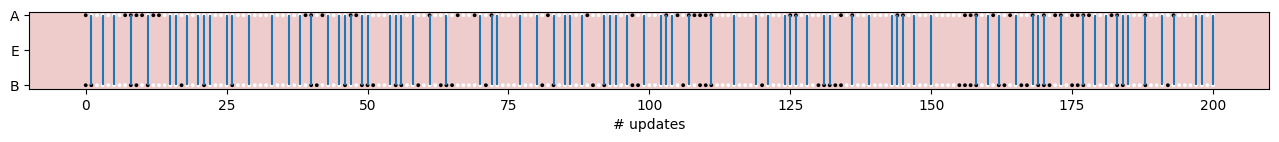

In [70]:
f = plt.figure(figsize=(16,1))
ax = f.subplots()
ax.grid(axis='x', which='minor')
ax.set_facecolor('#eecccc')

x = np.arange(n_updates+1, dtype=np.float16)
y0 = np.zeros_like(x)

ax.scatter(x, y0+1, s=3, c=np.where(Events[:,0], 'black', 'white'))
ax.scatter(x, y0-1, s=3, c=np.where(Events[:,1], 'black', 'white'))
ax.errorbar(np.where(Events[:,2], x, None), y0, yerr=1, fmt='none')

ax.set_xlabel('# updates')
ax.set_yticks((-1, 0, 1), ('B', 'E', 'A'))

plt.show()